In [1]:
import matplotlib.pyplot as plt
%matplotlib widget
from ipywidgets import *
import numpy as np
import pandas as pd
import sys
import taurex.log
taurex.log.disableLogging()
from taurex.cache import OpacityCache,CIACache
from taurex.temperature import Guillot2010
from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.model import TransmissionModel
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.binning import FluxBinner,SimpleBinner

Numba not installed, using numpy instead


In [ ]:
#Importing the opacity files (cross-sections and CIA)
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("/ca25/ext_volume/run_daneel/Assignment3_Atmospheres/xsecs")
CIACache().set_cia_path("/ca25/ext_volume/run_daneel/Assignment3_Atmospheres/cia/hitran")

h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']

In [5]:
# Set up the parameters and chemical abundances for the atmospheric model
guillot = Guillot2010(T_irr=284.0)
planet = Planet(planet_radius=0.211,planet_mass=0.028)
star = BlackbodyStar(temperature=3457.0,radius=0.41)
chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
molecules = ['H2O', 'CH4', 'CO2', 'CO']

def random_abundance(log_min=-8, log_max=-2):
    return 10**np.random.uniform(log_min, log_max)

# Dictionary to hold randomized values for verification of chemical abundances
random_values = {}

# Add each gas with its *own* randomized mixing ratio
for mol in molecules:
    val = random_abundance()
    random_values[mol] = val
    chemistry.addGas(ConstantGas(mol, mix_ratio=val))

# Check to verify that the chemical abundances are different
print("Randomized mixing ratios:")
for mol, val in random_values.items():
    print(f"{mol}: {val:.3e}")

Randomized mixing ratios:
H2O: 5.381e-05
CH4: 7.087e-07
CO2: 2.927e-03
CO: 6.752e-06


In [6]:
print(star.radius)

285237000.0


In [7]:
#Build the transmission model and add the contributions from physical processes
tm = TransmissionModel(planet=planet,
                       temperature_profile=guillot,
                       chemistry=chemistry,
                       star=star,
                        atm_min_pressure=1e-0,
                       atm_max_pressure=1e6,
                       nlayers=30)

tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())

tm.build()

In [8]:
#Run the model to get the transmission spectrum
res = tm.model()
res

(array([  199.99326855,   200.00660143,   200.01993521, ...,
        33328.88933329, 33331.11125925, 33333.33333333], shape=(76744,)),
 array([0.0029877 , 0.00298675, 0.00298627, ..., 0.00300686, 0.00300686,
        0.00300687], shape=(76744,)),
 array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         9.88328932e-194, 8.69255246e-194, 7.64500388e-194],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         2.07298765e-127, 1.90489978e-127, 1.75039909e-127],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         1.57355979e-083, 1.48880337e-083, 1.40858914e-083],
        ...,
        [9.99997871e-001, 9.99997973e-001, 9.99998021e-001, ...,
         9.97850472e-001, 9.97849847e-001, 9.97849222e-001],
        [9.99999213e-001, 9.99999251e-001, 9.99999268e-001, ...,
         9.98804402e-001, 9.98804054e-001, 9.98803706e-001],
        [9.99999750e-001, 9.99999762e-001, 9.99999768e-001, ...,
         9.99482770e-001, 9.99482620e-001, 9.9

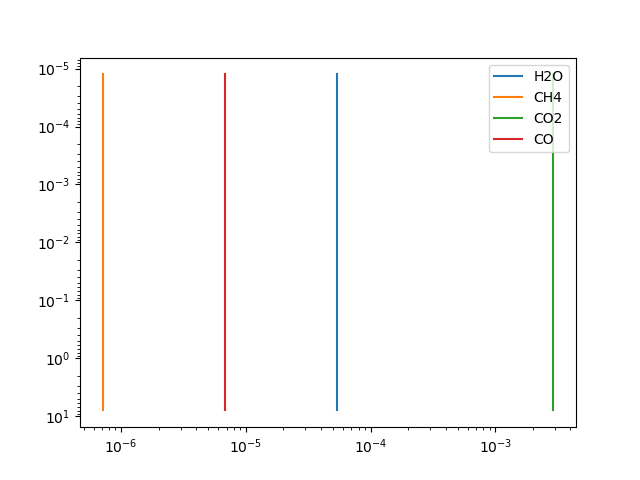

In [14]:
#Plot the atmospheric mixing ratio profiles
plt.figure()

for x,gasname in enumerate(tm.chemistry.activeGases):
    
    plt.plot(tm.chemistry.activeGasMixProfile[x],tm.pressureProfile/1e5,label=gasname)

plt.gca().invert_yaxis()
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

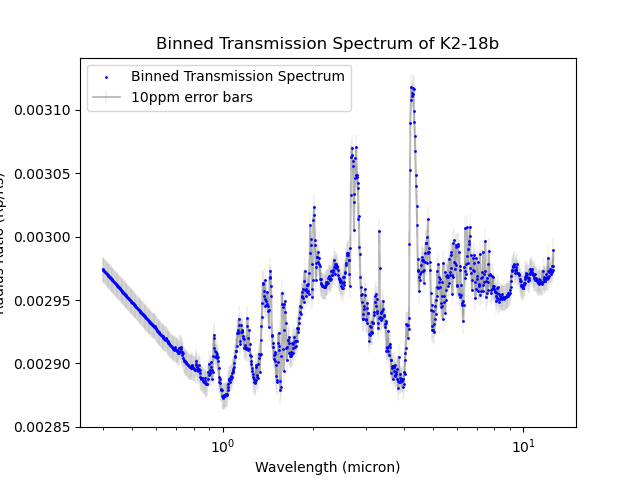

In [30]:
#Plot the binned transmission spectrum
native_grid, rprs, tau, _ = res
binned_fig = plt.figure()


#Make a logarithmic grid
wngrid = np.sort(10000/np.logspace(-0.4,1.1,1000))
bn = SimpleBinner(wngrid=wngrid)

bin_wn, bin_rprs,_,_  = bn.bin_model(tm.model(wngrid=wngrid))
errorbars = np.full_like(bin_rprs, 0.00001)

plt.scatter(10000/bin_wn, bin_rprs, label='Binned Transmission Spectrum', c='b', s=1, zorder=1)
plt.errorbar(10000/bin_wn,bin_rprs, yerr=errorbars, label='10ppm error bars', c='k', markersize=2, alpha=0.25, elinewidth=0.25, zorder=-1)
plt.xscale('log')
plt.title('Binned Transmission Spectrum of K2-18b')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Radius Ratio (Rp/Rs)')
plt.legend()
plt.show()

In [27]:
#Saving the output spectrum to a file
Data = np.zeros((len(bin_wn),3))
Data[:,0] = 10000/bin_wn
Data[:,1] = bin_rprs
Data[:,2] = errorbars
output_df = np.savetxt('K2-18b_assignment3_taskA_spectrum.dat', Data, header='Wavelength(micron) (rp/rs)^2 Error_Bars')


In [31]:
#Saving the plot of the binned transmission spectrum
binned_fig.savefig('K2-18b_assignment3_taskA_spectrum.png')

In [29]:
#Saving the input parameters of the model to a text file
with open('K2-18b_assignment3_taskA_parameters.txt', 'w') as f:
    f.write("Input Parameters for K2-18b Transmission Model\n")
    f.write("=============================================\n\n")
    f.write("Planet Parameters:\n")
    f.write(f"  Planet Radius (Rj): {0.211}\n")
    f.write(f"  Planet Mass (Mj): {0.028}\n\n")
    
    f.write("Star Parameters:\n")
    f.write(f"  Star Temperature (K): {star.temperature}\n")
    f.write(f"  Star Radius (Rs): {0.41}\n\n")
    
    f.write("Temperature Profile:\n")
    f.write(f"  Irradiation Temperature (T_irr): {guillot.T_irr}\n\n")
    
    f.write("Chemistry:\n")
    for mol in molecules:
        f.write(f"  {mol} Mixing Ratio: {random_values[mol]:.3e}\n")
    
    f.write("\nAtmospheric Pressure Range:\n")
    f.write(f"  Min Pressure (bar): {1e-0}\n")
    f.write(f"  Max Pressure (bar): {1e6}\n")
    f.write(f"  Number of Layers: {30}\n")